# 01 — Data Pipeline
Retrieve, clean and explore historical equity price data for portfolio risk analysis.

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [5]:
tickers = ["AAPL", "MSFT", "JPM", "JNJ", "XOM", 
           "AMZN", "PG", "BA", "GLD", "BRK-B"]

start_date = "2020-01-01"
end_date   = "2025-01-01"

In [6]:
raw = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

# Extract closing prices
prices = raw["Close"]
prices.dropna(how="all", inplace=True)

print(f"Data shape: {prices.shape}")
print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
prices.head()

[*********************100%***********************]  10 of 10 completed

Data shape: (1258, 10)
Date range: 2020-01-02 to 2024-12-31



/var/folders/9k/1454mj890x917jcjhgkh3thm0000gp/T/ipykernel_9959/870682326.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prices.dropna(how="all", inplace=True)


Ticker,AAPL,AMZN,BA,BRK-B,GLD,JNJ,JPM,MSFT,PG,XOM
Date,,,,,,,,,,
2020-01-02,72.400520,94.900497,331.348572,228.389999,143.949997,122.638237,119.036423,152.158371,105.524025,53.306416
2020-01-03,71.696648,93.748497,330.791901,226.179993,145.860001,121.218338,117.465569,150.263763,104.814323,52.877853
2020-01-06,72.267944,95.143997,331.766083,226.990005,147.389999,121.067101,117.372169,150.652161,104.959671,53.283852
2020-01-07,71.928047,95.343002,335.285156,225.919998,147.970001,121.806442,115.376770,149.278534,104.309822,52.847767
2020-01-08,73.085121,94.598503,329.410095,225.990005,146.860001,121.789635,116.276802,151.656311,104.754448,52.050812


In [7]:
missing = prices.isnull().sum()
print("Missing values per ticker:")
print(missing)

# Forward fill any minor gaps
prices = prices.ffill()

Missing values per ticker:
Ticker
AAPL     0
AMZN     0
BA       0
BRK-B    0
GLD      0
JNJ      0
JPM      0
MSFT     0
PG       0
XOM      0
dtype: int64


In [8]:
returns = prices.pct_change().dropna()

print(f"Returns shape: {returns.shape}")
returns.head()

Returns shape: (1257, 10)


Ticker,AAPL,AMZN,BA,BRK-B,GLD,JNJ,JPM,MSFT,PG,XOM
Date,,,,,,,,,,
2020-01-03,-0.009722,-0.012139,-0.001680,-0.009676,0.013269,-0.011578,-0.013196,-0.012452,-0.006725,-0.008040
2020-01-06,0.007968,0.014886,0.002945,0.003581,0.010490,-0.001248,-0.000795,0.002585,0.001387,0.007678
2020-01-07,-0.004703,0.002092,0.010607,-0.004714,0.003935,0.006107,-0.017001,-0.009118,-0.006191,-0.008184
2020-01-08,0.016087,-0.007809,-0.017523,0.000310,-0.007502,-0.000138,0.007801,0.015928,0.004263,-0.015080
2020-01-09,0.021241,0.004799,0.014998,0.011770,-0.005652,0.002967,0.003651,0.012493,0.010938,0.007656


In [9]:
stats = returns.describe().T
stats["skewness"] = returns.skew()
stats["kurtosis"] = returns.kurt()
stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
Ticker,,,,,,,,,,
AAPL,1257.0,0.001182,0.019956,-0.128647,-0.008425,0.001187,0.011989,0.119808,0.105626,5.277827
AMZN,1257.0,0.000923,0.022655,-0.140494,-0.011086,0.000782,0.012956,0.135359,0.070445,3.995553
BA,1257.0,0.000020,0.032178,-0.238484,-0.014606,-0.000419,0.013510,0.243186,0.248860,11.654657
BRK-B,1257.0,0.000639,0.013695,-0.095921,-0.005896,0.000675,0.007170,0.116099,0.091135,12.279660
GLD,1257.0,0.000462,0.009780,-0.053694,-0.004709,0.000618,0.005953,0.048530,-0.297191,2.557530
JNJ,1257.0,0.000179,0.012382,-0.072983,-0.005727,0.000122,0.005922,0.079977,0.434980,8.294414
JPM,1257.0,0.000746,0.020490,-0.149649,-0.008412,0.000709,0.009901,0.180125,0.448237,12.950844
MSFT,1257.0,0.000988,0.019211,-0.147390,-0.008176,0.001111,0.010940,0.142169,-0.016823,7.120289
PG,1257.0,0.000429,0.013181,-0.087374,-0.005533,0.000690,0.006867,0.120090,0.162106,12.625413


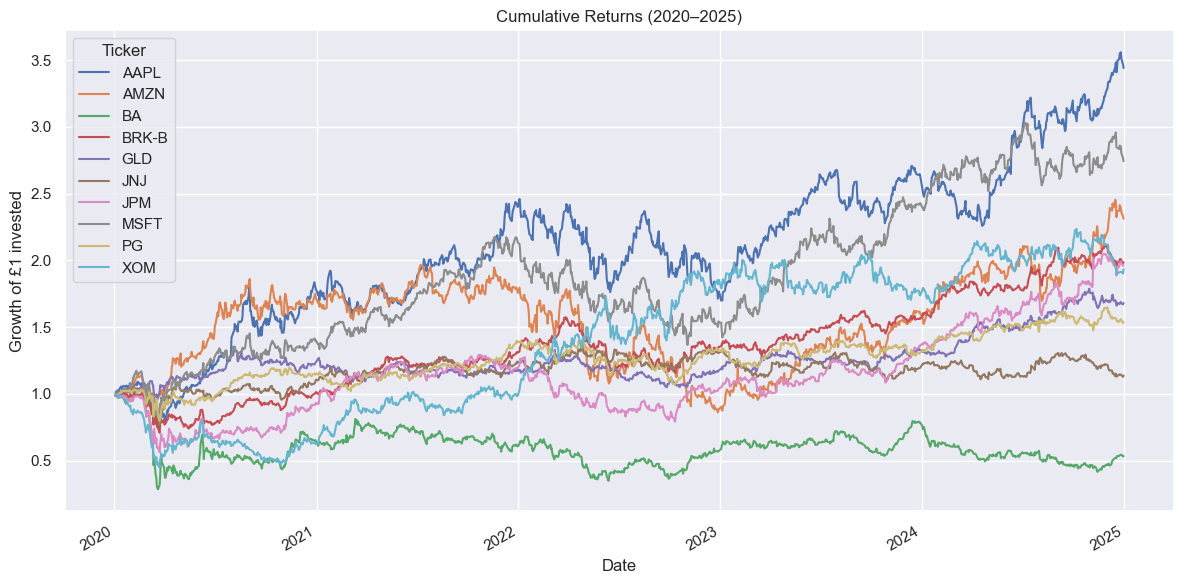

In [10]:
cumulative = (1 + returns).cumprod()

cumulative.plot(title="Cumulative Returns (2020–2025)")
plt.ylabel("Growth of £1 invested")
plt.xlabel("Date")
plt.tight_layout()
plt.savefig("../outputs/cumulative_returns.png", dpi=150)
plt.show()